# Performance Analytics — Mutual Fund Scheme Evaluation

Computes daily returns, CAGR, Sharpe/Sortino ratios, Alpha/Beta vs Nifty 100,
Maximum Drawdown, a composite Fund Scorecard, and a benchmark comparison chart
for all schemes in `data/raw/02_nav_history.csv`.

**Data note:** if `data/raw/` only has synthetic data (from `00_generate_synthetic_data.py`),
replace it with real `01_fund_master.csv`, `02_nav_history.csv`, and `10_benchmark_indices.csv`
— no code below needs to change, only the CSVs on disk.


In [1]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt

RAW_DIR = "../data/raw"
CLEAN_DIR = "../data/cleaned"
REPORT_DIR = "../reports"

RF = 0.065          # RBI repo-rate proxy, annualized risk-free rate
TRADING_DAYS = 252

pd.set_option("display.max_columns", None)
plt.style.use("seaborn-v0_8-whitegrid")

## Load Data

In [14]:
import os
os.chdir(r"C:\Users\HP\bluestock-mf-analytics\notebooks")
print(os.getcwd())

C:\Users\HP\bluestock-mf-analytics\notebooks


In [16]:
import os
RAW_DIR = r"C:\Users\HP\bluestock-mf-analytics\data\raw"
print(os.path.exists(RAW_DIR))
print(os.listdir(RAW_DIR))

True
['.gitkeep', '01_fund_master.csv', '02_mutual_funds.db', '02_nav_history.csv', '03_aum_by_fund_house.csv', '04_monthly_sip_inflows.csv', '05_category_inflows.csv', '06_industry_folio_count.csv', '07_scheme_performance.csv', '08_investor_transactions.csv', '09_portfolio_holdings.csv', '10_benchmark_indices.csv', 'axis_bluechip_nav.csv', 'hdfc_top100_live_nav.csv', 'icici_bluechip_nav.csv', 'kotak_bluechip_nav.csv', 'live_nav_axis_bluechip_119092.csv', 'live_nav_icici_bluechip_120503.csv', 'live_nav_kotak_bluechip_120841.csv', 'live_nav_nippon_large_cap_118632.csv', 'live_nav_sbi_bluechip_119551.csv', 'nippon_large_cap_nav.csv', 'sbi_bluechip_nav.csv']


In [22]:
import os
RAW_DIR = r"C:\Users\HP\bluestock-mf-analytics\data\raw"
print(os.path.exists(RAW_DIR))
print(os.listdir(RAW_DIR))

True
['.gitkeep', '01_fund_master.csv', '02_mutual_funds.db', '02_nav_history.csv', '03_aum_by_fund_house.csv', '04_monthly_sip_inflows.csv', '05_category_inflows.csv', '06_industry_folio_count.csv', '07_scheme_performance.csv', '08_investor_transactions.csv', '09_portfolio_holdings.csv', '10_benchmark_indices.csv', 'axis_bluechip_nav.csv', 'hdfc_top100_live_nav.csv', 'icici_bluechip_nav.csv', 'kotak_bluechip_nav.csv', 'live_nav_axis_bluechip_119092.csv', 'live_nav_icici_bluechip_120503.csv', 'live_nav_kotak_bluechip_120841.csv', 'live_nav_nippon_large_cap_118632.csv', 'live_nav_sbi_bluechip_119551.csv', 'nippon_large_cap_nav.csv', 'sbi_bluechip_nav.csv']


In [24]:
fund_master = pd.read_csv(f"{RAW_DIR}/01_fund_master.csv")
nav_history = pd.read_csv(f"{RAW_DIR}/02_nav_history.csv", parse_dates=["date"])
benchmark = pd.read_csv(f"{RAW_DIR}/10_benchmark_indices.csv", parse_dates=["date"])

nav_history = nav_history.sort_values(["amfi_code", "date"]).reset_index(drop=True)

print(f"Fund master:  {fund_master.shape}")
print(f"NAV history:  {nav_history.shape}  ({nav_history['amfi_code'].nunique()} schemes)")
print(f"Benchmark:    {benchmark.shape}")
fund_master.head()

Fund master:  (40, 15)
NAV history:  (52200, 4)  (40 schemes)
Benchmark:    (2610, 3)


,amfi_code,fund_house,scheme_name,category,sub_category,plan,launch_date,benchmark,expense_ratio_pct,exit_load_pct,min_sip_amount,min_lumpsum_amount,fund_manager,risk_category,sebi_category_code
0,100000,SBI MF,SBI MF Large Cap Fund - Direct Growth,Equity,Large Cap,Direct,2013-08-01,Nifty 100,1.54,1.0,2500,1000,Manager A,Moderate,EQ-1
1,100001,ICICI Prudential,ICICI Prudential Mid Cap Fund - Direct Growth,Equity,Mid Cap,Direct,2013-08-01,Nifty 50,1.02,1.0,2500,10000,Manager B,Moderate,EQ-2
2,100002,HDFC MF,HDFC MF Small Cap Fund - Direct Growth,Equity,Small Cap,Direct,2016-08-01,Nifty 100,0.56,1.0,1000,1000,Manager C,Moderately High,EQ-3
3,100003,Axis MF,Axis MF Flexi Cap Fund - Direct Growth,Equity,Flexi Cap,Direct,2012-08-01,Nifty 50,1.60,0.5,1000,1000,Manager D,Moderate,EQ-4
4,100004,Kotak MF,Kotak MF ELSS Fund - Direct Growth,Equity,ELSS,Direct,2008-08-01,Nifty 100,1.27,0.0,500,1000,Manager E,High,EQ-5


## Task 1 — Daily Returns

`daily_return = NAV_t / NAV_t-1 - 1`, computed per scheme, then validated for outliers.

In [27]:
nav_history["daily_return"] = nav_history.groupby("amfi_code")["nav"].pct_change()

returns_clean = nav_history["daily_return"].dropna()
print(f"count={len(returns_clean)}  mean={returns_clean.mean():.5f}  std={returns_clean.std():.5f}")
print(f"min={returns_clean.min():.4f}  max={returns_clean.max():.4f}")

outliers = returns_clean[returns_clean.abs() > 0.10]
print(f"Days with |daily_return| > 10% (possible data issue): {len(outliers)}")

count=52160  mean=0.00061  std=0.01502
min=-0.0756  max=0.0735
Days with |daily_return| > 10% (possible data issue): 0


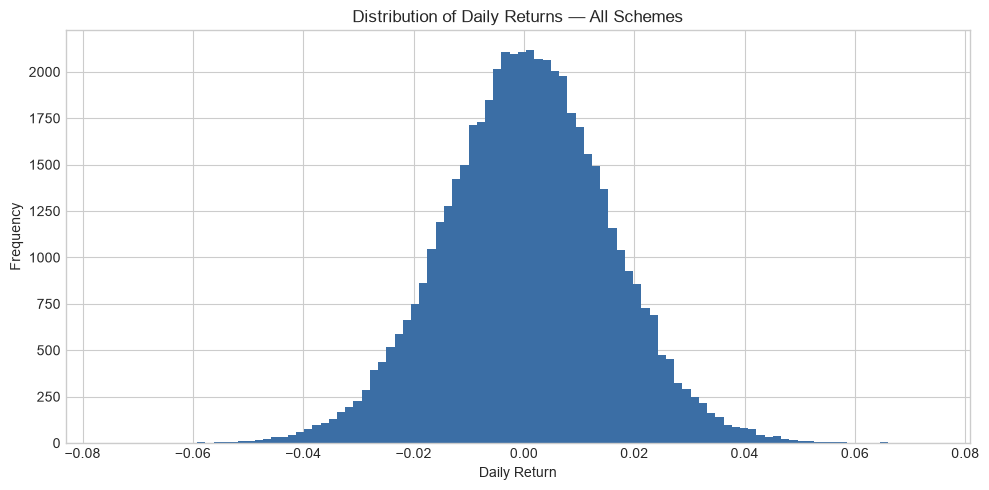

In [29]:
fig, ax = plt.subplots(figsize=(10, 5))
returns_clean.hist(bins=100, ax=ax, color="#3b6ea5")
ax.set_title("Distribution of Daily Returns — All Schemes")
ax.set_xlabel("Daily Return")
ax.set_ylabel("Frequency")
plt.tight_layout()
plt.show()

## Task 2 — CAGR (1yr / 3yr / 5yr)

`CAGR = (NAV_end / NAV_start) ^ (1/n) - 1`

In [32]:
def cagr(nav_series: pd.Series, years: float) -> float:
    nav_series = nav_series.dropna()
    if len(nav_series) < 2:
        return np.nan
    start_nav, end_nav = nav_series.iloc[0], nav_series.iloc[-1]
    return (end_nav / start_nav) ** (1 / years) - 1

latest_date = nav_history["date"].max()
cagr_rows = []
for code_, grp in nav_history.groupby("amfi_code"):
    grp = grp.sort_values("date")
    row = {"amfi_code": code_}
    for label, yrs in [("1yr", 1), ("3yr", 3), ("5yr", 5)]:
        cutoff = latest_date - pd.DateOffset(years=yrs)
        window = grp[grp["date"] >= cutoff]
        row[f"cagr_{label}_pct"] = round(cagr(window["nav"], yrs) * 100, 2) if len(window) > 1 else np.nan
    cagr_rows.append(row)

cagr_df = pd.DataFrame(cagr_rows)
cagr_comparison = cagr_df.merge(fund_master[["amfi_code", "scheme_name", "fund_house"]], on="amfi_code")
cagr_comparison = cagr_comparison[["amfi_code", "scheme_name", "fund_house", "cagr_1yr_pct", "cagr_3yr_pct", "cagr_5yr_pct"]]
cagr_comparison.sort_values("cagr_3yr_pct", ascending=False).head(10)

,amfi_code,scheme_name,fund_house,cagr_1yr_pct,cagr_3yr_pct,cagr_5yr_pct
35,100035,Nippon India Large Cap Fund - Direct Growth,Nippon India,37.41,53.15,42.49
10,100010,SBI MF Large Cap Fund - Direct Growth,SBI MF,24.10,38.91,24.96
4,100004,Kotak MF ELSS Fund - Direct Growth,Kotak MF,71.70,31.51,34.37
39,100039,DSP MF ELSS Fund - Direct Growth,DSP MF,66.83,27.33,26.93
30,100030,SBI MF Large Cap Fund - Direct Growth,SBI MF,69.38,27.32,33.30
27,100027,Mirae Asset Small Cap Fund - Direct Growth,Mirae Asset,55.66,25.51,14.91
6,100006,UTI MF Mid Cap Fund - Direct Growth,UTI MF,47.41,25.41,24.38
9,100009,DSP MF ELSS Fund - Direct Growth,DSP MF,86.94,24.93,24.72
28,100028,Franklin Templeton Flexi Cap Fund - Direct Growth,Franklin Templeton,88.76,24.62,26.40
11,100011,ICICI Prudential Mid Cap Fund - Direct Growth,ICICI Prudential,65.85,24.14,33.69


## Task 3 — Sharpe Ratio

`Sharpe = (Rp - Rf) / std(Rp) * sqrt(252)`, with Rf = 6.5% annualized (RBI repo rate proxy).

In [35]:
rf_daily = RF / TRADING_DAYS

sharpe_rows = []
for code_, grp in nav_history.groupby("amfi_code"):
    r = grp["daily_return"].dropna()
    sharpe = ((r.mean() - rf_daily) / r.std()) * np.sqrt(TRADING_DAYS) if r.std() > 0 else np.nan
    sharpe_rows.append({"amfi_code": code_, "sharpe_ratio": round(sharpe, 3)})

sharpe_df = pd.DataFrame(sharpe_rows)
sharpe_df["sharpe_rank"] = sharpe_df["sharpe_ratio"].rank(ascending=False, method="min").astype(int)
sharpe_df.merge(fund_master[["amfi_code", "scheme_name"]], on="amfi_code").sort_values("sharpe_rank").head(10)

,amfi_code,sharpe_ratio,sharpe_rank,scheme_name
35,100035,1.119,1,Nippon India Large Cap Fund - Direct Growth
4,100004,1.082,2,Kotak MF ELSS Fund - Direct Growth
11,100011,1.019,3,ICICI Prudential Mid Cap Fund - Direct Growth
30,100030,0.883,4,SBI MF Large Cap Fund - Direct Growth
6,100006,0.881,5,UTI MF Mid Cap Fund - Direct Growth
28,100028,0.880,6,Franklin Templeton Flexi Cap Fund - Direct Growth
39,100039,0.789,7,DSP MF ELSS Fund - Direct Growth
8,100008,0.719,8,Franklin Templeton Flexi Cap Fund - Direct Growth
9,100009,0.714,9,DSP MF ELSS Fund - Direct Growth
10,100010,0.684,10,SBI MF Large Cap Fund - Direct Growth


## Task 4 — Sortino Ratio

Same as Sharpe, but the denominator only uses downside deviation (std of negative-return days).

In [38]:
sortino_rows = []
for code_, grp in nav_history.groupby("amfi_code"):
    r = grp["daily_return"].dropna()
    downside_std = r[r < 0].std()
    sortino = ((r.mean() - rf_daily) / downside_std) * np.sqrt(TRADING_DAYS) if downside_std > 0 else np.nan
    sortino_rows.append({"amfi_code": code_, "sortino_ratio": round(sortino, 3)})

sortino_df = pd.DataFrame(sortino_rows)
sortino_df.merge(fund_master[["amfi_code", "scheme_name"]], on="amfi_code").sort_values("sortino_ratio", ascending=False).head(10)

,amfi_code,sortino_ratio,scheme_name
35,100035,1.890,Nippon India Large Cap Fund - Direct Growth
4,100004,1.867,Kotak MF ELSS Fund - Direct Growth
11,100011,1.750,ICICI Prudential Mid Cap Fund - Direct Growth
30,100030,1.503,SBI MF Large Cap Fund - Direct Growth
6,100006,1.472,UTI MF Mid Cap Fund - Direct Growth
28,100028,1.414,Franklin Templeton Flexi Cap Fund - Direct Growth
39,100039,1.345,DSP MF ELSS Fund - Direct Growth
9,100009,1.204,DSP MF ELSS Fund - Direct Growth
8,100008,1.193,Franklin Templeton Flexi Cap Fund - Direct Growth
10,100010,1.146,SBI MF Large Cap Fund - Direct Growth


## Task 5 — Alpha & Beta (CAPM regression vs Nifty 100)

OLS regression of each fund's daily returns on Nifty 100's daily returns using `scipy.stats.linregress`.
`Beta` = slope (market sensitivity). `Alpha` = intercept, annualized (`intercept * 252`).

In [41]:
nifty100 = benchmark[benchmark["index_name"] == "Nifty 100"].sort_values("date").copy()
nifty100["bench_return"] = nifty100["close_value"].pct_change()
bench_returns = nifty100[["date", "bench_return"]].dropna()

alpha_beta_rows = []
for code_, grp in nav_history.groupby("amfi_code"):
    merged = grp[["date", "daily_return"]].merge(bench_returns, on="date", how="inner").dropna()
    if len(merged) < 30:
        continue
    slope, intercept, r_value, p_value, std_err = stats.linregress(merged["bench_return"], merged["daily_return"])
    alpha_beta_rows.append({
        "amfi_code": code_,
        "beta": round(slope, 3),
        "alpha_annual_pct": round(intercept * TRADING_DAYS * 100, 3),
        "r_squared": round(r_value ** 2, 3),
        "p_value": round(p_value, 4),
    })

alpha_beta_df = pd.DataFrame(alpha_beta_rows)
alpha_beta_named = alpha_beta_df.merge(fund_master[["amfi_code", "scheme_name"]], on="amfi_code")
alpha_beta_named.sort_values("alpha_annual_pct", ascending=False).head(10)

,amfi_code,beta,alpha_annual_pct,r_squared,p_value,scheme_name
35,100035,0.948,27.183,0.302,0.0,Nippon India Large Cap Fund - Direct Growth
4,100004,1.114,18.128,0.647,0.0,Kotak MF ELSS Fund - Direct Growth
30,100030,1.251,17.295,0.511,0.0,SBI MF Large Cap Fund - Direct Growth
11,100011,1.212,16.765,0.691,0.0,ICICI Prudential Mid Cap Fund - Direct Growth
10,100010,0.752,16.529,0.202,0.0,SBI MF Large Cap Fund - Direct Growth
28,100028,0.940,13.814,0.552,0.0,Franklin Templeton Flexi Cap Fund - Direct Growth
6,100006,0.897,12.314,0.635,0.0,UTI MF Mid Cap Fund - Direct Growth
39,100039,1.259,11.416,0.693,0.0,DSP MF ELSS Fund - Direct Growth
8,100008,1.028,11.379,0.517,0.0,Franklin Templeton Flexi Cap Fund - Direct Growth
32,100032,1.033,10.642,0.408,0.0,HDFC MF Small Cap Fund - Direct Growth


## Task 6 — Maximum Drawdown

`Drawdown_t = NAV_t / running_max(NAV) - 1`. Max Drawdown is the minimum of that series;
we also locate the peak date and trough date defining the worst decline window.

In [44]:
def max_drawdown_with_dates(df: pd.DataFrame):
    df = df.sort_values("date").copy()
    df["running_max"] = df["nav"].cummax()
    df["drawdown"] = df["nav"] / df["running_max"] - 1
    trough_idx = df["drawdown"].idxmin()
    trough_row = df.loc[trough_idx]
    peak_row = df[(df["date"] <= trough_row["date"]) & (df["nav"] == df["running_max"])].iloc[-1]
    return trough_row["drawdown"], peak_row["date"], trough_row["date"]

mdd_rows = []
for code_, grp in nav_history.groupby("amfi_code"):
    dd, peak_date, trough_date = max_drawdown_with_dates(grp)
    mdd_rows.append({
        "amfi_code": code_,
        "max_drawdown_pct": round(dd * 100, 2),
        "drawdown_peak_date": peak_date.date(),
        "drawdown_trough_date": trough_date.date(),
    })

mdd_df = pd.DataFrame(mdd_rows)
mdd_df.merge(fund_master[["amfi_code", "scheme_name"]], on="amfi_code").sort_values("max_drawdown_pct").head(10)

,amfi_code,max_drawdown_pct,drawdown_peak_date,drawdown_trough_date,scheme_name
34,100034,-61.80,2021-09-03,2026-04-10,Kotak MF ELSS Fund - Direct Growth
3,100003,-56.37,2024-05-29,2025-09-15,Axis MF Flexi Cap Fund - Direct Growth
15,100015,-52.55,2023-09-05,2024-10-07,Nippon India Large Cap Fund - Direct Growth
22,100022,-50.43,2022-11-01,2024-10-31,HDFC MF Small Cap Fund - Direct Growth
31,100031,-47.45,2022-10-28,2025-10-17,ICICI Prudential Mid Cap Fund - Direct Growth
21,100021,-46.61,2022-11-16,2024-10-10,ICICI Prudential Mid Cap Fund - Direct Growth
14,100014,-46.33,2023-07-25,2025-12-05,Kotak MF ELSS Fund - Direct Growth
5,100005,-45.57,2022-12-09,2024-10-11,Nippon India Large Cap Fund - Direct Growth
25,100025,-45.34,2023-11-29,2025-12-09,Nippon India Large Cap Fund - Direct Growth
27,100027,-43.49,2022-06-21,2024-07-29,Mirae Asset Small Cap Fund - Direct Growth


## Task 7 — Fund Scorecard (0–100 composite)

Each metric is converted to a 0–100 percentile rank across all funds, then combined:

```
Score = 0.30 * rank(3yr return)
      + 0.25 * rank(Sharpe)
      + 0.20 * rank(Alpha)
      + 0.15 * rank(inverse expense ratio)   # lower expense = higher rank
      + 0.10 * rank(inverse max drawdown)    # smaller drawdown = higher rank
```

In [47]:
scorecard = (
    fund_master[["amfi_code", "scheme_name", "fund_house", "expense_ratio_pct"]]
    .merge(cagr_df[["amfi_code", "cagr_3yr_pct"]], on="amfi_code")
    .merge(sharpe_df[["amfi_code", "sharpe_ratio"]], on="amfi_code")
    .merge(alpha_beta_df[["amfi_code", "alpha_annual_pct", "beta"]], on="amfi_code")
    .merge(mdd_df[["amfi_code", "max_drawdown_pct"]], on="amfi_code")
)

n = len(scorecard)

def pct_rank(series: pd.Series, ascending: bool) -> pd.Series:
    r = series.rank(ascending=ascending, method="average")
    return (r - 1) / (n - 1) * 100

scorecard["rank_3yr_return"] = pct_rank(scorecard["cagr_3yr_pct"], ascending=True)
scorecard["rank_sharpe"] = pct_rank(scorecard["sharpe_ratio"], ascending=True)
scorecard["rank_alpha"] = pct_rank(scorecard["alpha_annual_pct"], ascending=True)
scorecard["rank_expense_inv"] = pct_rank(scorecard["expense_ratio_pct"], ascending=False)
scorecard["rank_max_dd_inv"] = pct_rank(scorecard["max_drawdown_pct"], ascending=True)

scorecard["fund_score"] = (
    0.30 * scorecard["rank_3yr_return"]
    + 0.25 * scorecard["rank_sharpe"]
    + 0.20 * scorecard["rank_alpha"]
    + 0.15 * scorecard["rank_expense_inv"]
    + 0.10 * scorecard["rank_max_dd_inv"]
).round(2)

scorecard = scorecard.sort_values("fund_score", ascending=False).reset_index(drop=True)
scorecard.insert(0, "overall_rank", scorecard.index + 1)

scorecard.to_csv(f"{CLEAN_DIR}/fund_scorecard.csv", index=False)
alpha_beta_named.to_csv(f"{CLEAN_DIR}/alpha_beta.csv", index=False)

scorecard[["overall_rank", "scheme_name", "fund_house", "fund_score"]].head(10)

,overall_rank,scheme_name,fund_house,fund_score
0,1,Nippon India Large Cap Fund - Direct Growth,Nippon India,94.23
1,2,SBI MF Large Cap Fund - Direct Growth,SBI MF,88.72
2,3,Kotak MF ELSS Fund - Direct Growth,Kotak MF,86.41
3,4,SBI MF Large Cap Fund - Direct Growth,SBI MF,85.90
4,5,UTI MF Mid Cap Fund - Direct Growth,UTI MF,84.36
5,6,DSP MF ELSS Fund - Direct Growth,DSP MF,82.18
6,7,DSP MF ELSS Fund - Direct Growth,DSP MF,79.17
7,8,ICICI Prudential Mid Cap Fund - Direct Growth,ICICI Prudential,79.10
8,9,Franklin Templeton Flexi Cap Fund - Direct Growth,Franklin Templeton,74.10
9,10,HDFC MF Small Cap Fund - Direct Growth,HDFC MF,70.71


## Task 8 — Benchmark Comparison (Top 5 vs Nifty 50 / Nifty 100)

Plots cumulative growth of ₹100 invested 3 years ago in the top-5 scored funds vs both benchmarks.
Tracking error = `std(fund_return - benchmark_return) * sqrt(252)`.

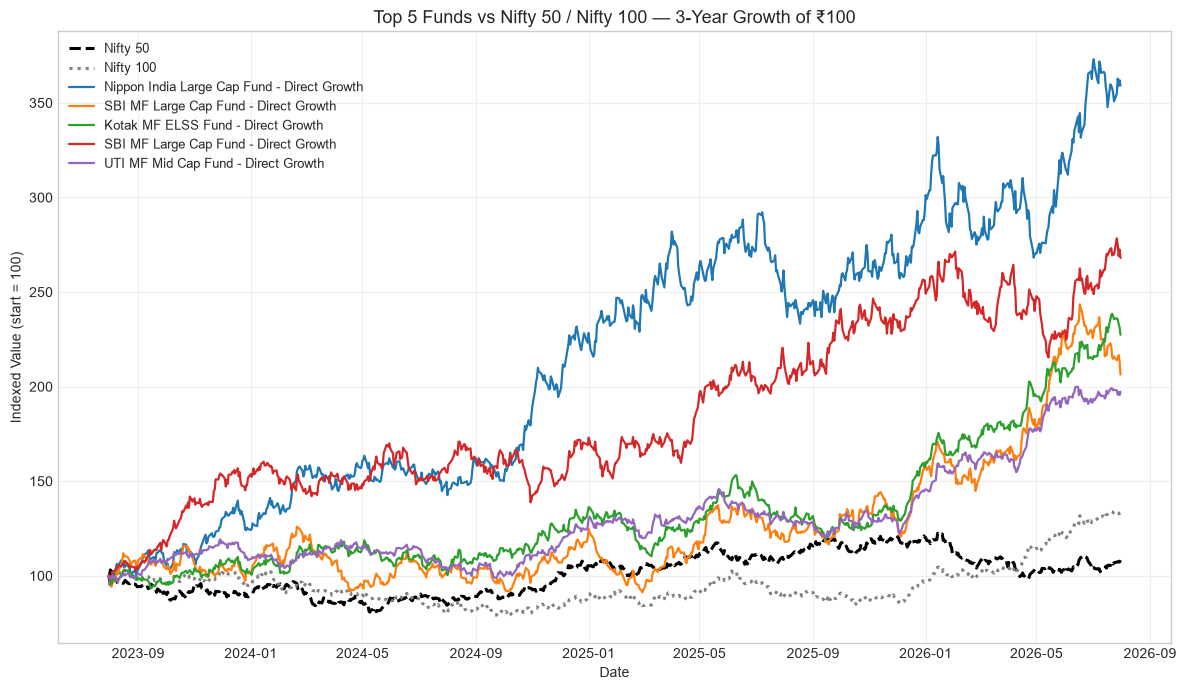

,amfi_code,scheme_name,tracking_error_vs_nifty100_pct
0,100035,Nippon India Large Cap Fund - Direct Growth,24.21
1,100030,SBI MF Large Cap Fund - Direct Growth,20.52
2,100004,Kotak MF ELSS Fund - Direct Growth,13.48
3,100010,SBI MF Large Cap Fund - Direct Growth,24.13
4,100006,UTI MF Mid Cap Fund - Direct Growth,11.50


In [50]:
top5_codes = scorecard.head(5)["amfi_code"].tolist()
cutoff_3yr = latest_date - pd.DateOffset(years=3)

nifty50 = benchmark[benchmark["index_name"] == "Nifty 50"].sort_values("date")
nifty50_3y = nifty50[nifty50["date"] >= cutoff_3yr].copy()
nifty100_3y = nifty100[nifty100["date"] >= cutoff_3yr].copy()
nifty50_3y["indexed"] = nifty50_3y["close_value"] / nifty50_3y["close_value"].iloc[0] * 100
nifty100_3y["indexed"] = nifty100_3y["close_value"] / nifty100_3y["close_value"].iloc[0] * 100

plt.figure(figsize=(12, 7))
plt.plot(nifty50_3y["date"], nifty50_3y["indexed"], label="Nifty 50", linewidth=2.2, linestyle="--", color="black")
plt.plot(nifty100_3y["date"], nifty100_3y["indexed"], label="Nifty 100", linewidth=2.2, linestyle=":", color="gray")

tracking_error_rows = []
for code_ in top5_codes:
    grp = nav_history[(nav_history["amfi_code"] == code_) & (nav_history["date"] >= cutoff_3yr)].sort_values("date").copy()
    grp["indexed"] = grp["nav"] / grp["nav"].iloc[0] * 100
    name = fund_master.loc[fund_master["amfi_code"] == code_, "scheme_name"].values[0]
    plt.plot(grp["date"], grp["indexed"], label=name, linewidth=1.6)

    merged = grp[["date", "daily_return"]].merge(bench_returns, on="date", how="inner").dropna()
    te = (merged["daily_return"] - merged["bench_return"]).std() * np.sqrt(TRADING_DAYS)
    tracking_error_rows.append({"amfi_code": code_, "scheme_name": name, "tracking_error_vs_nifty100_pct": round(te * 100, 2)})

plt.title("Top 5 Funds vs Nifty 50 / Nifty 100 — 3-Year Growth of ₹100", fontsize=13)
plt.xlabel("Date")
plt.ylabel("Indexed Value (start = 100)")
plt.legend(loc="upper left", fontsize=9)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f"{REPORT_DIR}/benchmark_comparison.png", dpi=150)
plt.show()

pd.DataFrame(tracking_error_rows)